# ALFWorld episode history analysis

Use this notebook to find, compare, and inspect individual episodes in `history.json`. The sample file is a JSON array with one record per episode and a nested `steps` list.

**Quick start**

1. Run all cells once.
2. Edit `EPISODE_IDS` and the optional filters in **Select episodes**.
3. Re-run from that cell downward.
4. Use `show_episode(...)` for a readable trajectory and `search_episodes(...)` to locate relevant episodes.

The loader treats every string in the history file as data. It never evaluates decisions, actions, or observations as code.

In [3]:
from __future__ import annotations

import json
import os
import re
from collections import Counter
from pathlib import Path
from typing import Any, Iterable

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 140)

# Override this cell or set the HISTORY_PATH environment variable when the file moves.
PATH_CANDIDATES = [
    Path.cwd().parent.parent / "results/alfworld/4b_actions_hidden/history.json",
]
HISTORY_PATH = next((path for path in PATH_CANDIDATES if path and path.is_file()), None)
if HISTORY_PATH is None:
    raise FileNotFoundError("Set HISTORY_PATH to the location of history.json")

print(f"Using {HISTORY_PATH.resolve()}")

Using /home/y/yixiang/Ctrl-G/results/alfworld/4b_actions_hidden/history.json


## Load and normalize

Both a JSON array and JSON Lines (`.jsonl`) are accepted. The nested data is normalized into three tables: one row per episode, one row per step, and one row per sampled candidate.

In [4]:
def load_history(path: Path) -> list[dict[str, Any]]:
    text = path.read_text(encoding="utf-8")
    try:
        payload = json.loads(text)
    except json.JSONDecodeError:
        payload = [json.loads(line) for line in text.splitlines() if line.strip()]

    if not isinstance(payload, list) or not all(isinstance(row, dict) for row in payload):
        raise ValueError("Expected a JSON array or JSONL stream of episode objects")
    return payload


episodes = load_history(HISTORY_PATH)
required_episode_fields = {"episode", "steps", "success"}
for position, record in enumerate(episodes):
    missing = required_episode_fields - record.keys()
    if missing:
        raise ValueError(f"Episode record {position} is missing {sorted(missing)}")
    if not isinstance(record["steps"], list):
        raise ValueError(f"Episode record {position} has a non-list 'steps' value")

episode_ids = [record["episode"] for record in episodes]
if len(episode_ids) != len(set(episode_ids)):
    raise ValueError("Episode IDs must be unique")

episode_rows: list[dict[str, Any]] = []
step_rows: list[dict[str, Any]] = []
candidate_rows: list[dict[str, Any]] = []

for episode in episodes:
    steps = episode.get("steps", [])
    episode_rows.append({
        "episode": episode.get("episode"),
        "task_key": episode.get("task_key"),
        "success": bool(episode.get("success")),
        "n_steps": len(steps),
        "task_description": episode.get("task_description"),
        "gamefile": episode.get("gamefile"),
        "initial_observation": episode.get("initial_observation"),
        "fallback_steps": sum(bool(step.get("fallback_used")) for step in steps),
        "retry_count": sum(int(step.get("empty_action_retries") or 0) for step in steps),
        "sample_attempts": sum(int(step.get("sample_attempts") or 0) for step in steps),
    })

    for step_position, step in enumerate(steps):
        candidates = step.get("candidates") or []
        step_rows.append({
            "episode": episode.get("episode"),
            "task_key": episode.get("task_key"),
            "success": bool(episode.get("success")),
            "step": step.get("step", step_position),
            "action": step.get("action_taken", step.get("action")),
            "model_action": step.get("selected_model_action"),
            "decision": step.get("selected_model_decision", step.get("decision")),
            "observation": step.get("observation"),
            "selected_sample": step.get("selected_sample"),
            "sample_attempts": step.get("sample_attempts"),
            "empty_action_retries": step.get("empty_action_retries"),
            "fallback_used": bool(step.get("fallback_used")),
            "fallback_reason": step.get("fallback_reason"),
            "fallback_policy": step.get("fallback_policy"),
            "n_candidates": len(candidates),
        })

        for candidate_position, candidate in enumerate(candidates):
            candidate_rows.append({
                "episode": episode.get("episode"),
                "task_key": episode.get("task_key"),
                "success": bool(episode.get("success")),
                "step": step.get("step", step_position),
                "sample": candidate.get("sample", candidate_position),
                "selected": candidate.get("sample", candidate_position) == step.get("selected_sample"),
                "model_action": candidate.get("model_action"),
                "model_decision": candidate.get("model_decision"),
                "action_was_admissible": candidate.get("action_was_admissible"),
                "parse_ok": candidate.get("parse_ok"),
                "parse_errors": candidate.get("parse_errors") or [],
                "distill_eligible": candidate.get("distill_eligible"),
                "distill_exclusion_reasons": candidate.get("distill_exclusion_reasons") or [],
            })

episode_df = pd.DataFrame(episode_rows).sort_values("episode").reset_index(drop=True)
step_df = pd.DataFrame(step_rows)
candidate_df = pd.DataFrame(candidate_rows)
episode_lookup = {record["episode"]: record for record in episodes}

print(f"Loaded {len(episode_df):,} episodes, {len(step_df):,} steps, and {len(candidate_df):,} candidates.")

Loaded 100 episodes, 2,393 steps, and 2,396 candidates.


## Dataset overview

,value
episodes,100
successful,84
success_rate,84.0%
total_steps,"2,393"
median_steps,20
fallback_steps,0


,episodes,success_rate,median_steps,max_steps
task_key,,,,
heat,17,70.6%,28.0,50
cool,14,71.4%,21.0,50
puttwo,17,76.5%,31.0,50
clean,12,91.7%,20.0,50
put,28,92.9%,13.5,50
examine,12,100.0%,8.0,44


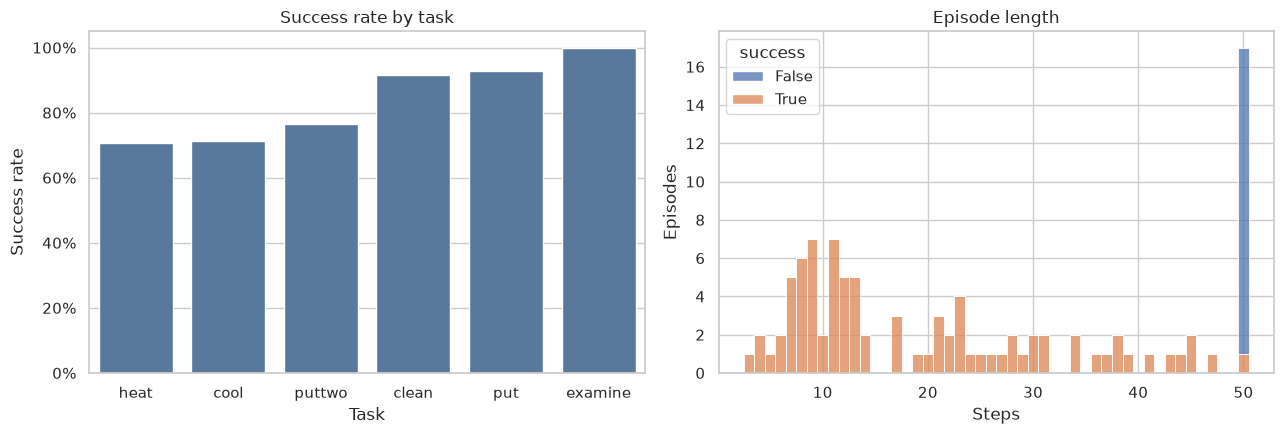

In [5]:
overview = pd.Series({
    "episodes": len(episode_df),
    "successful": int(episode_df["success"].sum()),
    "success_rate": episode_df["success"].mean(),
    "total_steps": int(episode_df["n_steps"].sum()),
    "median_steps": episode_df["n_steps"].median(),
    "fallback_steps": int(episode_df["fallback_steps"].sum()),
}, name="value").to_frame()
display(overview.style.format({"value": lambda value: f"{value:.1%}" if 0 < value < 1 else f"{value:,.0f}"}))

task_summary = (
    episode_df.groupby("task_key", dropna=False)
    .agg(episodes=("episode", "size"), success_rate=("success", "mean"),
         median_steps=("n_steps", "median"), max_steps=("n_steps", "max"))
    .sort_values("success_rate")
)
display(task_summary.style.format({"success_rate": "{:.1%}", "median_steps": "{:.1f}"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=task_summary.reset_index(), x="task_key", y="success_rate", ax=axes[0], color="#4C78A8")
axes[0].set(title="Success rate by task", xlabel="Task", ylabel="Success rate", ylim=(0, 1.05))
axes[0].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
sns.histplot(data=episode_df, x="n_steps", hue="success", multiple="stack", discrete=True, ax=axes[1])
axes[1].set(title="Episode length", xlabel="Steps", ylabel="Episodes")
plt.tight_layout()
plt.show()

## Select episodes

Filters are combined with AND. Leave a filter empty or `None` to disable it. Explicit `EPISODE_IDS` are also filtered by the other settings. The defaults compare one successful and one failed trajectory from the sample.

In [6]:
# --- Edit these values ---
EPISODE_IDS: list[int] = [2,7,28,39,40,42,43,47,55,58,74,81,82,89,92,95,99]     # [] means any episode
TASK_KEYS: list[str] = []            # e.g. ["cool", "heat"]
SUCCESS: bool | None = None          # True, False, or None
DESCRIPTION_CONTAINS = ""          # case-insensitive substring
MIN_STEPS: int | None = None
MAX_STEPS: int | None = None
# -------------------------

selected_df = episode_df.copy()
if EPISODE_IDS:
    selected_df = selected_df[selected_df["episode"].isin(EPISODE_IDS)]
if TASK_KEYS:
    selected_df = selected_df[selected_df["task_key"].isin(TASK_KEYS)]
if SUCCESS is not None:
    selected_df = selected_df[selected_df["success"].eq(SUCCESS)]
if DESCRIPTION_CONTAINS:
    selected_df = selected_df[selected_df["task_description"].fillna("").str.contains(
        DESCRIPTION_CONTAINS, case=False, regex=False
    )]
if MIN_STEPS is not None:
    selected_df = selected_df[selected_df["n_steps"].ge(MIN_STEPS)]
if MAX_STEPS is not None:
    selected_df = selected_df[selected_df["n_steps"].le(MAX_STEPS)]

selected_ids = selected_df["episode"].tolist()
if not selected_ids:
    print("No episodes matched. Relax the filters above.")
else:
    display(selected_df[["episode", "task_key", "success", "n_steps", "fallback_steps",
                         "retry_count", "task_description"]].style
            .format({"success": lambda value: "yes" if value else "no"})
            .hide(axis="index"))

episode,task_key,success,n_steps,fallback_steps,retry_count,task_description
2,cool,no,50,0,0,put a cool egg in garbagecan.
7,cool,no,50,0,0,put a cool apple in garbagecan.
28,heat,no,50,0,0,put a hot tomato in fridge.
39,heat,no,50,0,0,put a hot plate in cabinet.
40,puttwo,no,50,0,0,find two soapbottle and put them in countertop.
42,heat,no,50,0,0,put a hot plate in countertop.
43,examine,yes,44,0,0,examine the box with the desklamp.
47,put,no,50,0,0,put some tomato on microwave.
55,heat,no,50,0,0,put a hot plate in diningtable.
58,clean,no,50,0,0,put a clean cup in microwave.


## Read individual trajectories

`show_episode` displays the initial state followed by one row per action. Long text wraps in the table. Set `show_decisions=False` for a compact action/observation transcript.

In [7]:
def _clip(value: Any, max_chars: int | None) -> Any:
    if value is None or max_chars is None:
        return value
    text = str(value)
    return text if len(text) <= max_chars else text[: max_chars - 1] + "…"


def show_episode(episode_id: int, *, show_decisions: bool = True, show_candidates: bool = False,
                 max_chars: int | None = 500) -> pd.DataFrame:
    if episode_id not in episode_lookup:
        raise KeyError(f"Unknown episode {episode_id}. Available range: {min(episode_lookup)}–{max(episode_lookup)}")

    episode = episode_lookup[episode_id]
    status = "✅ success" if episode.get("success") else "❌ failure"
    display(Markdown(
        f"### Episode {episode_id} — {status}\n\n"
        f"**Task:** `{episode.get('task_key', 'unknown')}` — {episode.get('task_description', '')}  \n"
        f"**Steps:** {len(episode.get('steps', []))}  \n"
        f"**Initial observation:** {episode.get('initial_observation', '')}"
    ))

    rows = []
    for position, step in enumerate(episode.get("steps", [])):
        row = {
            "step": step.get("step", position),
            "action": _clip(step.get("action_taken", step.get("action")), max_chars),
            "observation": _clip(step.get("observation"), max_chars),
            "attempts": step.get("sample_attempts"),
            "retries": step.get("empty_action_retries"),
            "fallback": bool(step.get("fallback_used")),
        }
        if show_decisions:
            row["decision"] = _clip(step.get("selected_model_decision", step.get("decision")), max_chars)
        rows.append(row)

    trajectory = pd.DataFrame(rows)
    display(trajectory.style.set_properties(**{"white-space": "pre-wrap", "text-align": "left"}).hide(axis="index"))

    if show_candidates:
        candidates = candidate_df[candidate_df["episode"].eq(episode_id)].copy()
        display(Markdown("#### Candidate samples"))
        display(candidates.style.set_properties(**{"white-space": "pre-wrap", "text-align": "left"}).hide(axis="index"))
    return trajectory


for episode_id in selected_ids:
    show_episode(episode_id, show_decisions=True, show_candidates=False, max_chars=500)

### Episode 2 — ❌ failure

**Task:** `cool` — put a cool egg in garbagecan.  
**Steps:** 50  
**Initial observation:** You are in the middle of a room. Looking quickly around you, you see a cabinet 26, a cabinet 25, a cabinet 24, a cabinet 23, a cabinet 22, a cabinet 21, a cabinet 20, a cabinet 19, a cabinet 18, a cabinet 17, a cabinet 16, a cabinet 15, a cabinet 14, a cabinet 13, a cabinet 12, a cabinet 11, a cabinet 10, a cabinet 9, a cabinet 8, a cabinet 7, a cabinet 6, a cabinet 5, a cabinet 4, a cabinet 3, a cabinet 2, a cabinet 1, a coffeemachine 1, a countertop 3, a countertop 2, a countertop 1, a drawer 12, a drawer 11, a drawer 10, a drawer 9, a drawer 8, a drawer 7, a drawer 6, a drawer 5, a drawer 4, a drawer 3, a drawer 2, a drawer 1, a fridge 1, a garbagecan 1, a microwave 1, a sinkbasin 1, a stoveburner 4, a stoveburner 3, a stoveburner 2, a stoveburner 1, and a toaster 1.

step,action,observation,attempts,retries,fallback,decision
0,go to cabinet 1,"You arrive at cabinet 1. On the cabinet 1, you see a soapbottle 1.",1,0,False,"{task: cool, target_type: egg, target_id: unknown, target_location: unknown, held: none, at: unknown, dest: garbagecan 1, search: {locations_searched: [], locations_to_search: [cabinet 1, cabinet 2, ...]}, phase: search}"
1,go to cabinet 2,You arrive at cabinet 2. The cabinet 2 is closed.,1,0,False,"Task: cool, target_type: egg, target_id: unknown, target_location: unknown, held: none, at: cabinet 1, state: unknown, tool: unknown, dest: garbagecan 1, search: {locations_searched: [cabinet 1], locations_to_search: [cabinet 2, cabinet 3, ..., cabinet 26]}, phase: search"
2,go to fridge 1,You arrive at fridge 1. The fridge 1 is closed.,1,0,False,"{task: cool, target_type: egg, target_id: unknown, target_location: unknown, held: none, at: cabinet 2, dest: garbagecan 1, search: {locations_searched: [cabinet 1, cabinet 2], locations_to_search: [fridge 1, countertop 1, countertop 2, countertop 3, cabinet 3, ...]}, phase: search}"
3,open fridge 1,"You open the fridge 1. The fridge 1 is open. In it, you see a apple 3, a apple 2, a cup 2, a lettuce 3, a lettuce 2, and a potato 1.",1,0,False,"task: cool target_type: egg target_id: unknown target_location: unknown held: none at: fridge 1 dest: garbagecan 1 search: locations_searched: [cabinet 1] locations_to_search: [cabinet 2, cabinet 3, cabinet 4, cabinet 5, cabinet 6, cabinet 7, cabinet 8, cabinet 9, cabinet 10, cabinet 11, cabinet 12, cabinet 13, cabinet 14, cabinet 15, cabinet 16, cabinet 17, cabinet 18, cabinet 19, cabinet 20, cabinet 21, cabinet 22, cabinet 23, cabinet 24, cabinet 25, cabinet 26, drawer 1, drawer 2, drawer…"
4,go to cabinet 2,You arrive at cabinet 2. The cabinet 2 is closed.,1,0,False,"{task: cool, target_type: egg, target_id: unknown, target_location: unknown, held: none, at: fridge 1, state: unmodified, tool: FRIDGE, dest: garbagecan 1, search: {locations_searched: [cabinet 1, fridge 1], locations_to_search: [cabinet 2, cabinet 3, ...]}, phase: search}"
5,open cabinet 2,"You open the cabinet 2. The cabinet 2 is open. In it, you see nothing.",1,0,False,"{task: cool, target_type: egg, target_id: unknown, target_location: unknown, held: none, at: cabinet 2, state: unknown, tool: unknown, dest: garbagecan 1, search: {locations_searched: [cabinet 1, fridge 1], locations_to_search: [cabinet 2, cabinet 3, cabinet 4, cabinet 5, cabinet 6, cabinet 7, cabinet 8, cabinet 9, cabinet 10, cabinet 11, cabinet 12, cabinet 13, cabinet 14, cabinet 15, cabinet 16, cabinet 17, cabinet 18, cabinet 19, cabinet 20, cabinet 21, cabinet 22, cabinet 23, cabinet 24, ca…"
6,go to cabinet 3,You arrive at cabinet 3. The cabinet 3 is closed.,1,0,False,"{task: cool, target_type: egg, target_id: unknown, target_location: unknown, held: none, at: cabinet 2, state: unknown, tool: fridge 1, dest: garbagecan 1, search: {locations_searched: [cabinet 1, cabinet 2, fridge 1], locations_to_search: [cabinet 3, cabinet 4, cabinet 5, cabinet 6, cabinet 7, cabinet 8, cabinet 9, cabinet 10, cabinet 11, cabinet 12, cabinet 13, cabinet 14, cabinet 15, cabinet 16, cabinet 17, cabinet 18, cabinet 19, cabinet 20, cabinet 21, cabinet 22, cabinet 23, cabinet 24, c…"
7,open cabinet 3,"You open the cabinet 3. The cabinet 3 is open. In it, you see nothing.",1,0,False,"{task: cool, target_type: egg, target_id: unknown, target_location: unknown, held: none, at: cabinet 3, state: unmodified, tool: fridge 1, dest: garbagecan 1, search: {locations_searched: [cabinet 1, fridge 1, cabinet 2], locations_to_search: [cabinet 3, cabinet 4, cabinet 5, countertop 1, countertop 2, countertop 3, microwave 1, sinkbasin 1, stoveburner 1, stoveburner 2, stoveburner 3, stoveburner 4, toaster 1, coffeemachine 1]}, phase: search}"
8,go to cabinet 4,You arrive at cabinet 4. The cabinet 4 is closed.,1,0,False,"{task: cool, target_type: egg, target_id: unknown, target_location: unknown, h

### Episode 7 — ❌ failure

**Task:** `cool` — put a cool apple in garbagecan.  
**Steps:** 50  
**Initial observation:** You are in the middle of a room. Looking quickly around you, you see a cabinet 20, a cabinet 19, a cabinet 18, a cabinet 17, a cabinet 16, a cabinet 15, a cabinet 14, a cabinet 13, a cabinet 12, a cabinet 11, a cabinet 10, a cabinet 9, a cabinet 8, a cabinet 7, a cabinet 6, a cabinet 5, a cabinet 4, a cabinet 3, a cabinet 2, a cabinet 1, a coffeemachine 1, a countertop 2, a countertop 1, a diningtable 2, a diningtable 1, a drawer 6, a drawer 5, a drawer 4, a drawer 3, a drawer 2, a drawer 1, a fridge 1, a garbagecan 1, a microwave 1, a sinkbasin 1, a stoveburner 4, a stoveburner 3, a stoveburner 2, a stoveburner 1, and a toaster 1.

step,action,observation,attempts,retries,fallback,decision
0,go to countertop 1,"You arrive at countertop 1. On the countertop 1, you see a cellphone 1, a potato 1, a saltshaker 2, a soapbottle 2, a soapbottle 1, a spoon 1, and a tomato 1.",1,0,False,"{task: cool, target_type: apple, target_id: unknown, target_location: unknown, held: none, at: unknown, dest: garbagecan 1, search: {locations_searched: [], locations_to_search: [countertop 1, diningtable 1, diningtable 2, countertop 2, drawer 1, drawer 2, drawer 3, drawer 4, drawer 5, drawer 6, cabinet 1, cabinet 2, cabinet 3, cabinet 4, cabinet 5, cabinet 6, cabinet 7, cabinet 8, cabinet 9, cabinet 10, cabinet 11, cabinet 12, cabinet 13, cabinet 14, cabinet 15, cabinet 16, cabinet 17, cabinet…"
1,go to countertop 2,"You arrive at countertop 2. On the countertop 2, you see a bowl 1, a cellphone 3, a fork 3, a glassbottle 1, a pan 1, a spoon 2, and a spraybottle 1.",1,0,False,"task: cool, target_type: apple, target_id: unknown, target_location: unknown, held: none, at: countertop 1, state: unmodified, tool: unknown, dest: garbagecan 1, search: {locations_searched: [countertop 1], locations_to_search: [countertop 2, diningtable 1, diningtable 2, cabinet 1, cabinet 2, ...]}, phase: search"
2,go to cabinet 1,"You arrive at cabinet 1. On the cabinet 1, you see nothing.",1,0,False,"{task: puttwo, target_type: apple, required_count: 1, targets: [{id: apple unknown, location: unknown, status: unknown}], held: none, at: countertop 2, dest: garbagecan 1, search: {locations_searched: [countertop 1, countertop 2], locations_to_search: [cabinet 1]}}"
3,go to fridge 1,You arrive at fridge 1. The fridge 1 is closed.,1,0,False,"{task: cool, target_type: apple, target_id: unknown, target_location: unknown, held: none, at: cabinet 1, state: unknown, tool: unknown, dest: garbagecan 1, search: {locations_searched: [countertop 1, countertop 2, cabinet 1], locations_to_search: [fridge 1, cabinet 2, cabinet 3, cabinet 4, cabinet 5, cabinet 6, cabinet 7, cabinet 8, cabinet 9, cabinet 10, cabinet 11, cabinet 12, cabinet 13, cabinet 14, cabinet 15, cabinet 16, cabinet 17, cabinet 18, cabinet 19, drawer 1, drawer 2, drawer 3, dr…"
4,open fridge 1,"You open the fridge 1. The fridge 1 is open. In it, you see a bread 2, a lettuce 1, and a mug 1.",1,0,False,"{task: cool, target_type: apple, target_id: unknown, target_location: unknown, held: none, at: fridge 1, dest: garbagecan 1, tool: fridge 1, state: unmodified, search: {locations_searched: [countertop 1, countertop 2, cabinet 1], locations_to_search: [fridge 1]}, phase: search}"
5,go to cabinet 2,"You arrive at cabinet 2. On the cabinet 2, you see nothing.",1,0,False,"{task: cool, target_type: apple, target_id: unknown, target_location: unknown, held: none, at: fridge 1, state: unmodified, tool: fridge 1, dest: garbagecan 1, search: {locations_searched: [countertop 1, countertop 2, cabinet 1, fridge 1], locations_to_search: [cabinet 2, drawer 1, drawer 2, drawer 3, drawer 4, drawer 5, drawer 6]}}"
6,go to cabinet 3,Nothing happens.,1,0,False,"task: cool target_type: apple target_id: unknown target_location: unknown held: none at: cabinet 2 dest: garbagecan 1 search: {locations_searched: [countertop 1, countertop 2, cabinet 1, fridge 1, cabinet 2], locations_to_search: [cabinet 3, cabinet 4, cabinet 5, cabinet 6, cabinet 7, cabinet 8, cabinet 9, cabinet 10, cabinet 11, cabinet 12, cabinet 13, cabinet 14, cabinet 15, cabinet 16, cabinet 17, cabinet 18, cabinet 19, cabinet 20, diningtable 1, diningtable 2, drawer 1, drawer 2, drawer 3,…"
7,go to cabinet 4,"You arrive at cabinet 4. On the cabinet 4, you see nothing.",1,0,False,"{task: cool, target_type: apple, target_id: unknown, target_location: unknown, held: none, at: cabinet 3, state: unmodified, tool: unknown, dest: garbagecan 1, search: {locations_searched: [countertop 1, countertop 2, cabinet 1, fridge 1, cabinet 2, cabinet 3], locations_to_search: [cabinet 4, cabinet 5, cabinet 6, cabinet 7, cabinet 8

### Episode 28 — ❌ failure

**Task:** `heat` — put a hot tomato in fridge.  
**Steps:** 50  
**Initial observation:** You are in the middle of a room. Looking quickly around you, you see a cabinet 13, a cabinet 12, a cabinet 11, a cabinet 10, a cabinet 9, a cabinet 8, a cabinet 7, a cabinet 6, a cabinet 5, a cabinet 4, a cabinet 3, a cabinet 2, a cabinet 1, a coffeemachine 1, a countertop 1, a drawer 5, a drawer 4, a drawer 3, a drawer 2, a drawer 1, a fridge 1, a garbagecan 1, a microwave 1, a sinkbasin 1, a stoveburner 4, a stoveburner 3, a stoveburner 2, a stoveburner 1, and a toaster 1.

...

step,action,observation,attempts,retries,fallback,decision
0,look,"You are in the middle of a room. Looking quickly around you, you see nothing.",1,0,False,"task: puttwo, target_type: soapbar, required_count: 2, targets: [{id: unknown, location: unknown, status: available}, {id: unknown, location: unknown, status: available}], held: none, at: room (middle), dest: cabinet 1, search: {locations_searched: [], locations_to_search: [cabinet 1, cabinet 2, cabinet 3, cabinet 4, countertop 1, garbagecan 1, sinkbasin 1, sinkbasin 2, toilet 1, toiletpaperhanger 1, towelholder 1]}, phase: search}"
1,look,"You are in the middle of a room. Looking quickly around you, you see nothing.",1,0,False,"{task: puttwo, target_type: soapbar, required_count: 2, targets: [{id: unknown, location: unknown, status: unknown}, {id: unknown, location: unknown, status: unknown}], held: none, at: middle of room, dest: cabinet 1, search: {locations_searched: [], locations_to_search: [cabinet 1, cabinet 2, cabinet 3, cabinet 4, countertop 1, sinkbasin 1, sinkbasin 2, handtowelholder 1, garbagecan 1, toiletpaperhanger 1, towelholder 1, toilet 1]}}"
2,go to sinkbasin 1,"You arrive at sinkbasin 1. On the sinkbasin 1, you see nothing.",1,0,False,"{task: puttwo, target_type: soapbar, required_count: 2, targets: [{id: soapbar 1, location: unknown, status: available}, {id: soapbar 2, location: unknown, status: available}], held: none, at: middle of room, dest: unknown, search: {locations_searched: [], locations_to_search: [sinkbasin 1, sinkbasin 2, countertop 1, cabinet 1, cabinet 2, cabinet 3, cabinet 4]}, phase: search}"
3,go to cabinet 1,You arrive at cabinet 1. The cabinet 1 is closed.,1,0,False,"{task: puttwo, target_type: soapbar, required_count: 2, targets: [{id: unknown, location: unknown, status: unknown}, {id: unknown, location: unknown, status: unknown}], held: none, at: sinkbasin 1, dest: unknown, search: {locations_searched: [sinkbasin 1], locations_to_search: [cabinet 1, cabinet 2, cabinet 3, cabinet 4, sinkbasin 2, countertop 1, toilet 1, handtowelholder 1, towelholder 1, toiletpaperhanger 1, garbagecan 1]}}"
4,open cabinet 1,"You open the cabinet 1. The cabinet 1 is open. In it, you see a cloth 1, and a soapbottle 1.",1,0,False,"task: puttwo target_type: soapbar required_count: 2 targets: [{id: unknown, location: unknown, status: unknown}, {id: unknown, location: unknown, status: unknown}] held: none at: cabinet 1 dest: unknown search: {locations_searched: [sinkbasin 1], locations_to_search: [cabinet 1, cabinet 2, cabinet 3, cabinet 4, countertop 1, garbagecan 1, handtowelholder 1, sinkbasin 2, toilet 1, toiletpaperhanger 1, towelholder 1]}, phase: acquire_first"
5,go to cabinet 2,You arrive at cabinet 2. The cabinet 2 is closed.,1,0,False,"{task: puttwo, target_type: soapbar, target_id: unknown, target_location: unknown, held: none, at: cabinet 1, dest: unknown, search: {locations_searched: [""cabinet 1""], locations_to_search: [""cabinet 2"", ""cabinet 3"", ""cabinet 4"", ""countertop 1"", ""garbagecan 1"", ""handtowelholder 1"", ""sinkbasin 2"", ""sinkbasin 1"", ""toiletpaperhanger 1"", ""towelholder 1"", ""toilet 1""]}, phase: search}"
6,open cabinet 2,"You open the cabinet 2. The cabinet 2 is open. In it, you see nothing.",1,0,False,"task: puttwo target_type: soapbar required_count: 2 targets: [{id: soapbar unknown, location: unknown, status: available}, {id: soapbar unknown, location: unknown, status: available}] held: none at: cabinet 2 dest: cabinet 1 search: {locations_searched: [sinkbasin 1, cabinet 1], locations_to_search: [cabinet 2, cabinet 3, cabinet 4, countertop 1]} phase: acquire"
7,go to cabinet 3,You arrive at cabinet 3. The cabinet 3 is closed.,1,0,False,"{task: puttwo, target_type: soapbar, target_id: unknown, target_location: unknown, held: none, at: cabinet 2, dest: unknown, search: {locations_searched: [sinkbasin 1, cabinet 1, cabinet 2], locations_to_search: [cabinet 3, cabinet 4]}, phase: search}"
8,open cabinet 3,"You open th

### Episode 95 — ❌ failure

**Task:** `puttwo` — find two pen and put them in sidetable.  
**Steps:** 50  
**Initial observation:** You are in the middle of a room. Looking quickly around you, you see a bed 2, a bed 1, a diningtable 1, a drawer 2, a drawer 1, a garbagecan 1, a shelf 14, a shelf 13, a shelf 12, a shelf 11, a shelf 10, a shelf 9, a shelf 8, a shelf 7, a shelf 6, a shelf 5, a shelf 4, a shelf 3, a shelf 2, a shelf 1, and a sidetable 1.

step,action,observation,attempts,retries,fallback,decision
0,go to drawer 1,You arrive at drawer 1. The drawer 1 is closed.,1,0,False,"{task: puttwo, target_type: pen, required_count: 2, targets: [{id: pen 1, location: unknown, status: available}, {id: pen 2, location: unknown, status: available}], held: none, at: middle of room, dest: sidetable 1, search: {locations_searched: [], locations_to_search: [drawer 1, drawer 2, diningtable 1]}}"
1,open drawer 1,"You open the drawer 1. The drawer 1 is open. In it, you see a creditcard 1.",1,0,False,"{task: puttwo, target_type: pen, required_count: 2, held: none, at: drawer 1, dest: sidetable 1, search: {locations_searched: [], locations_to_search: [drawer 1]}, phase: search}"
2,go to drawer 2,You arrive at drawer 2. The drawer 2 is closed.,1,0,False,"task: puttwo, target_type: pen, required_count: 2, targets: [{id: unknown, location: unknown, status: unknown}, {id: unknown, location: unknown, status: unknown}], held: none, at: drawer 1, dest: sidetable 1, search: {locations_searched: [drawer 1], locations_to_search: [bed 1, bed 2, diningtable 1, drawer 2, garbagecan 1, shelf 1, shelf 10, shelf 14, sidetable 1]}, phase: search"
3,open drawer 2,"You open the drawer 2. The drawer 2 is open. In it, you see a creditcard 2.",1,0,False,"task: puttwo target_type: pen required_count: 2 targets: [{id: pen 1, location: unknown, status: unknown}, {id: pen 2, location: unknown, status: unknown}] held: none at: drawer 2 dest: sidetable 1 search: {locations_searched: [drawer 1], locations_to_search: [drawer 2, bed 1, bed 2, diningtable 1, shelf 1, shelf 2, ...]} phase: search"
4,go to shelf 1,"You arrive at shelf 1. On the shelf 1, you see nothing.",1,0,False,"{task: puttwo, target_type: pen, required_count: 2, targets: [{id: pen unknown, location: unknown, status: available}, {id: pen unknown, location: unknown, status: available}], held: none, at: drawer 2, dest: sidetable 1, search: {locations_searched: [drawer 1, drawer 2], locations_to_search: [shelf 1, diningtable 1, bed 1, bed 2, garbagecan 1, shelf 2, shelf 3, shelf 4, shelf 5, shelf 6, shelf 7, shelf 8, shelf 9, shelf 10, shelf 11, shelf 12, shelf 13, shelf 14]}, phase: search}"
5,go to shelf 2,"You arrive at shelf 2. On the shelf 2, you see nothing.",1,0,False,"Search for first pen. Currently at shelf 1 with no pens found. Need to continue searching remaining locations. Next location: shelf 2. Locations searched: drawer 1, drawer 2, shelf 1. Locations to search: shelf 2, shelf 3, shelf 4, shelf 5, shelf 6, shelf 7, shelf 8, shelf 9, shelf 10, shelf 11, shelf 12, shelf 13, shelf 14, bed 1, bed 2, diningtable 1, garbagecan 1. Phase: search"
6,go to shelf 3,"You arrive at shelf 3. On the shelf 3, you see nothing.",1,0,False,"{task: puttwo, target_type: pen, required_count: 2, targets: [{id: pen 1, location: unknown, status: unknown}, {id: pen 2, location: unknown, status: unknown}], held: none, at: shelf 2, dest: sidetable 1, search: {locations_searched: [drawer 1, drawer 2, shelf 1, shelf 2], locations_to_search: [shelf 3, shelf 4, shelf 5, shelf 6, shelf 7, shelf 8, shelf 9, shelf 10, shelf 11, shelf 12, shelf 13, shelf 14, diningtable 1, garbagecan 1, bed 1, bed 2]}, phase: search}"
7,go to shelf 4,"You arrive at shelf 4. On the shelf 4, you see nothing.",1,0,False,"{task: puttwo, target_type: pen, required_count: 2, targets: [{id: pen unknown, location: unknown, status: unknown}, {id: pen unknown, location: unknown, status: unknown}], held: none, at: shelf 3, dest: sidetable 1, search: {locations_searched: [drawer 1, drawer 2, shelf 1, shelf 2, shelf 3], locations_to_search: [shelf 4, shelf 5, shelf 6, shelf 7, shelf 8, shelf 9, shelf 10, shelf 11, shelf 12, shelf 13, shelf 14, diningtable 1, bed 1, bed 2, garbagecan 1, sidetable 1]}, phase: search}"
8,go to shelf 5,"You arrive at shelf 5. On the shelf 5, you see a bowl 3, and a bowl 2.",1,0,False,"task: puttwo target_type: pen required_count: 2 targets: [] held: none at: shelf 4 dest: s

### Episode 99 — ❌ failure

**Task:** `puttwo` — find two peppershaker and put them in diningtable.  
**Steps:** 50  
**Initial observation:** You are in the middle of a room. Looking quickly around you, you see a cabinet 21, a cabinet 20, a cabinet 19, a cabinet 18, a cabinet 17, a cabinet 16, a cabinet 15, a cabinet 14, a cabinet 13, a cabinet 12, a cabinet 11, a cabinet 10, a cabinet 9, a cabinet 8, a cabinet 7, a cabinet 6, a cabinet 5, a cabinet 4, a cabinet 3, a cabinet 2, a cabinet 1, a coffeemachine 1, a countertop 2, a countertop 1, a diningtable 1, a drawer 5, a drawer 4, a drawer 3, a drawer 2, a drawer 1, a fridge 1, a garbagecan 1, a microwave 1, a sinkbasin 1, a stoveburner 4, a stoveburner 3, a stoveburner 2, a stoveburner 1, and a toaster 1.

step,action,observation,attempts,retries,fallback,decision
0,open cabinet 1,Nothing happens.,1,0,False,"task: puttwo, target_type: peppershaker, required_count: 2, targets: [{id: unknown, location: unknown, status: unknown}], held: none, at: unknown, dest: diningtable 1, search: {locations_searched: [], locations_to_search: [cabinet 1, cabinet 2, ..., cabinet 21]}, phase: search"
1,open cabinet 2,Nothing happens.,1,0,False,"task: puttwo, target_type: peppershaker, required_count: 2, targets: [{id: peppershaker 1, location: unknown, status: unknown}, {id: peppershaker 2, location: unknown, status: unknown}], held: none, at: cabinet 1, dest: diningtable 1, search: {locations_searched: [cabinet 1], locations_to_search: [cabinet 2, cabinet 3, countertop 1, countertop 2, diningtable 1]}, phase: search"
2,go to cabinet 3,You arrive at cabinet 3. The cabinet 3 is closed.,1,0,False,"task: puttwo, target_type: peppershaker, required_count: 2, targets: [], held: none, at: cabinet 2, dest: diningtable 1, search: {locations_searched: [cabinet 1, cabinet 2], locations_to_search: [cabinet 3, cabinet 4, cabinet 5, cabinet 6, cabinet 7, cabinet 8, cabinet 9, cabinet 10, cabinet 11, cabinet 12, cabinet 13, cabinet 14, cabinet 15, cabinet 16, cabinet 17, cabinet 18, cabinet 19, cabinet 20, cabinet 21]}, phase: search"
3,open cabinet 3,"You open the cabinet 3. The cabinet 3 is open. In it, you see nothing.",1,0,False,"{task: puttwo, target_type: peppershaker, required_count: 2, targets: [{id: unknown, location: unknown, status: available}], held: none, at: cabinet 3, dest: diningtable 1, search: {locations_searched: [cabinet 1, cabinet 2], locations_to_search: [cabinet 3, cabinet 4, cabinet 5, cabinet 6, cabinet 7, cabinet 8, cabinet 9, cabinet 10, cabinet 11, cabinet 12, cabinet 13, cabinet 14, cabinet 15, cabinet 16, cabinet 17, cabinet 18, cabinet 19, cabinet 20, cabinet 21]}, phase: search}"
4,go to cabinet 4,You arrive at cabinet 4. The cabinet 4 is closed.,1,0,False,"task: puttwo target_type: peppershaker required_count: 2 targets: [ {id: unknown, location: unknown, status: unknown}, {id: unknown, location: unknown, status: unknown} ] held: none at: cabinet 3 dest: diningtable 1 search: locations_searched: [cabinet 1, cabinet 2, cabinet 3] locations_to_search: [cabinet 4, cabinet 5, cabinet 6, cabinet 7, cabinet 8, cabinet 9, cabinet 10, cabinet 11, cabinet 12, cabinet 13, cabinet 14, cabinet 15, cabinet 16, cabinet 17, cabin…"
5,go to cabinet 5,"You arrive at cabinet 5. On the cabinet 5, you see nothing.",1,0,False,"{task: puttwo, target_type: peppershaker, required_count: 2, targets: [{id: unknown, location: unknown, status: unknown}, {id: unknown, location: unknown, status: unknown}], held: none, at: cabinet 4, dest: diningtable 1, search: {locations_searched: [cabinet 1, cabinet 2, cabinet 3, cabinet 4], locations_to_search: [cabinet 5, cabinet 6, cabinet 7, cabinet 8, cabinet 9, cabinet 10, cabinet 11, cabinet 12, cabinet 13, cabinet 14, cabinet 15, cabinet 16, cabinet 17, cabinet 18, cabinet 19, cabin…"
6,go to cabinet 6,You arrive at cabinet 6. The cabinet 6 is closed.,1,0,False,"{task: puttwo, target_type: peppershaker, required_count: 2, targets: [{id: unknown, location: unknown, status: unknown}, {id: unknown, location: unknown, status: unknown}], held: none, at: cabinet 5, dest: diningtable 1, search: {locations_searched: [cabinet 1, cabinet 2, cabinet 3, cabinet 4, cabinet 5], locations_to_search: [cabinet 6, cabinet 7, cabinet 8, cabinet 9, cabinet 10, cabinet 11, cabinet 12, cabinet 13, cabinet 14, cabinet 15, cabinet 16, cabinet 17, cabinet 18, cabinet 19, cabin…"
7,open cabinet 6,"You open the cabinet 6. The cabinet 6 is open. In it, you see a peppershaker 1.",1,0,False,"task: puttwo, target_type: peppershaker, required_count: 2, targets: [{id: unknown, location: unknown, status: available}, {id: unknown, location: unknown, status: available}], held: none, at: cabinet 6, dest: diningtable 1, search: {locations_searched: [ca

## Compare selected episodes

The first plot shows how actions accumulate over time. The second flags steps that had retries, fallbacks, inadmissible samples, parse failures, or distillation exclusions.

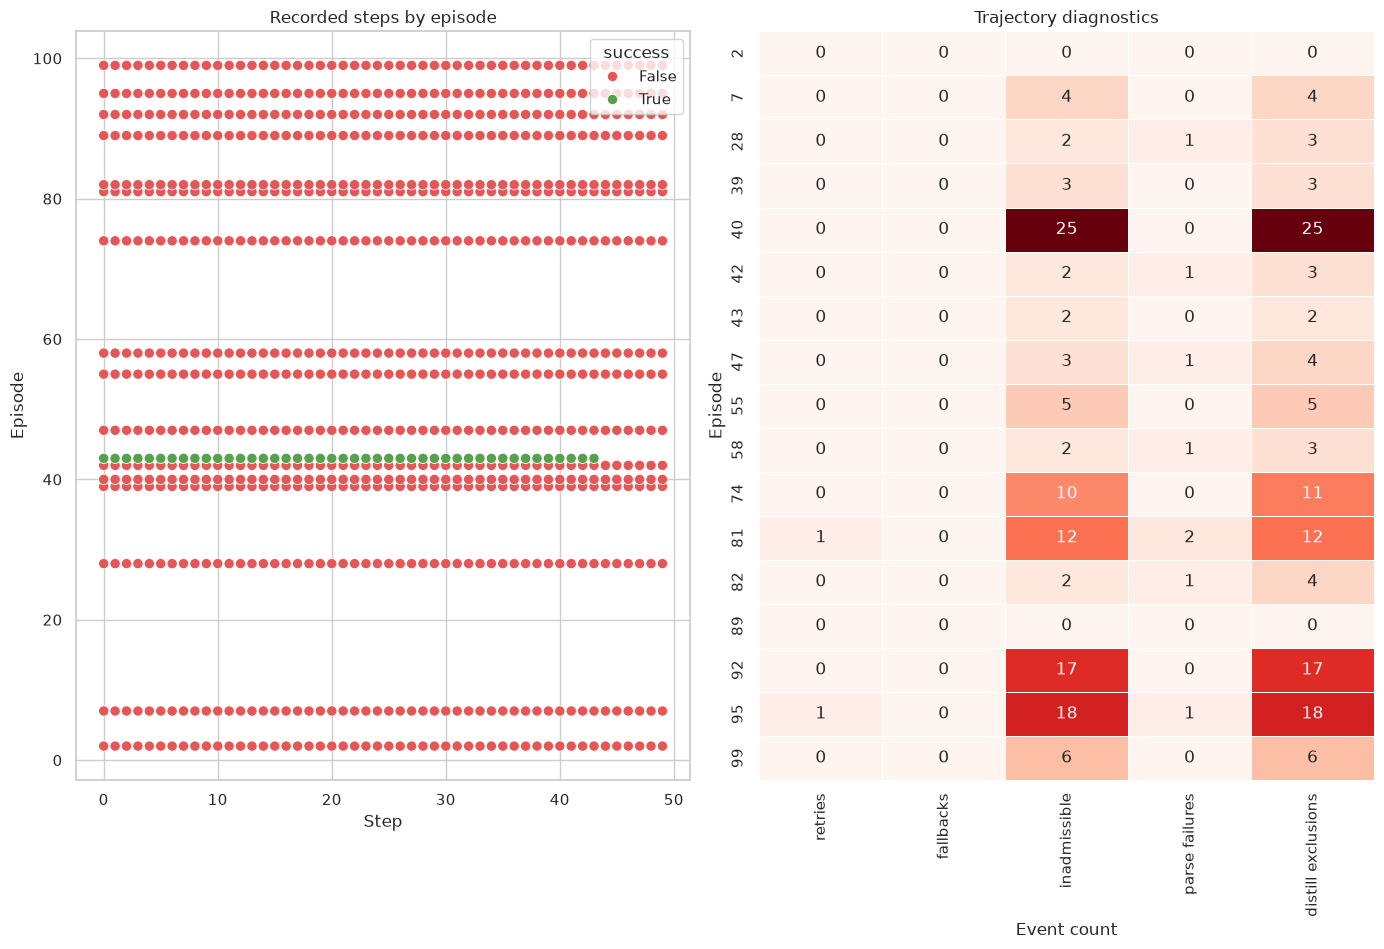

,retries,fallbacks,inadmissible,parse failures,distill exclusions
episode,,,,,
2,0,0,0,0,0
7,0,0,4,0,4
28,0,0,2,1,3
39,0,0,3,0,3
40,0,0,25,0,25
42,0,0,2,1,3
43,0,0,2,0,2
47,0,0,3,1,4
55,0,0,5,0,5


In [8]:
selected_steps = step_df[step_df["episode"].isin(selected_ids)].copy()
selected_candidates = candidate_df[candidate_df["episode"].isin(selected_ids)].copy()

if not selected_ids:
    print("Select at least one episode above.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, 0.45 * len(selected_ids) + 2)))
    sns.scatterplot(data=selected_steps, x="step", y="episode", hue="success",
                    palette={True: "#54A24B", False: "#E45756"}, s=55, ax=axes[0])
    axes[0].set(title="Recorded steps by episode", xlabel="Step", ylabel="Episode")

    diagnostics = []
    for episode_id in selected_ids:
        eps = selected_steps[selected_steps["episode"].eq(episode_id)]
        cand = selected_candidates[selected_candidates["episode"].eq(episode_id)]
        diagnostics.append({
            "episode": episode_id,
            "retries": int(eps["empty_action_retries"].fillna(0).sum()),
            "fallbacks": int(eps["fallback_used"].sum()),
            "inadmissible": int(cand["action_was_admissible"].eq(False).sum()),
            "parse failures": int(cand["parse_ok"].eq(False).sum()),
            "distill exclusions": int(cand["distill_eligible"].eq(False).sum()),
        })
    diagnostic_df = pd.DataFrame(diagnostics).set_index("episode")
    sns.heatmap(diagnostic_df, annot=True, fmt="g", cmap="Reds", cbar=False, linewidths=0.5, ax=axes[1])
    axes[1].set(title="Trajectory diagnostics", xlabel="Event count", ylabel="Episode")
    plt.tight_layout()
    plt.show()
    display(diagnostic_df)

## Action patterns

Actions are grouped by their first verb to make loops and policy differences easier to spot.

In [9]:
def action_verb(action: Any) -> str:
    if not isinstance(action, str) or not action.strip():
        return "<empty>"
    return action.strip().split(maxsplit=1)[0].lower()


if selected_steps.empty:
    print("Select at least one episode above.")
else:
    action_counts = (selected_steps.assign(action_verb=selected_steps["action"].map(action_verb))
                     .groupby(["episode", "action_verb"]).size().rename("count").reset_index())
    pivot = action_counts.pivot(index="episode", columns="action_verb", values="count").fillna(0).astype(int)
    display(pivot.style.background_gradient(cmap="Blues", axis=None))

    repeated = []
    for episode_id, group in selected_steps.sort_values(["episode", "step"]).groupby("episode"):
        actions = group["action"].fillna("<empty>").tolist()
        runs = []
        start = 0
        for index in range(1, len(actions) + 1):
            if index == len(actions) or actions[index] != actions[start]:
                if index - start > 1:
                    runs.append({"episode": episode_id, "start_step": int(group.iloc[start]["step"]),
                                 "run_length": index - start, "action": actions[start]})
                start = index
        repeated.extend(runs)
    display(Markdown("**Consecutive repeated-action runs**"))
    display(pd.DataFrame(repeated) if repeated else Markdown("No consecutive repeated actions in the selection."))

action_verb,...,clean,close,cool,examine,go,heat,inventory,look,move,open,put,take,use
episode,,,,,,,,,,,,,,
2,0,0,0,0,0,38,0,0,0,0,12,0,0,0
7,0,0,0,0,0,39,0,0,7,0,4,0,0,0
28,0,0,0,0,0,35,0,0,5,0,10,0,0,0
39,1,0,0,0,0,33,0,0,8,0,8,0,0,0
40,0,0,0,0,2,17,0,0,3,3,5,1,19,0
42,0,0,0,0,0,37,0,0,1,0,12,0,0,0
43,0,0,0,0,0,33,0,0,2,0,7,0,1,1
47,0,0,0,0,0,34,0,0,3,0,13,0,0,0
55,0,0,0,0,0,36,0,0,8,0,5,0,1,0


**Consecutive repeated-action runs**

,episode,start_step,run_length,action
0,7,46,4,look
1,39,0,3,look
2,39,19,2,look
3,40,19,2,move soapbottle 1 to countertop 1
4,40,24,4,take soapbottle 2 from toilet 1
5,40,42,2,take soapbottle 2 from toilet 1
6,40,45,3,take soapbottle 2 from toilet 1
7,43,0,2,look
8,55,47,2,look
9,58,0,2,look


## Search for episodes

Search across task descriptions, initial observations, decisions, actions, and observations. By default the query is treated as plain text; pass `regex=True` for a regular expression.

In [10]:
def search_episodes(query: str, *, regex: bool = False, case: bool = False) -> pd.DataFrame:
    if not query:
        return episode_df.iloc[0:0].copy()
    pattern = re.compile(query if regex else re.escape(query), 0 if case else re.IGNORECASE)
    matches = []
    for episode in episodes:
        fields: list[tuple[str, Any]] = [
            ("task_description", episode.get("task_description")),
            ("initial_observation", episode.get("initial_observation")),
        ]
        for position, step in enumerate(episode.get("steps", [])):
            step_number = step.get("step", position)
            fields.extend([
                (f"step {step_number} decision", step.get("selected_model_decision", step.get("decision"))),
                (f"step {step_number} action", step.get("action_taken", step.get("action"))),
                (f"step {step_number} observation", step.get("observation")),
            ])
        hit_locations = [label for label, value in fields if value is not None and pattern.search(str(value))]
        if hit_locations:
            matches.append({
                "episode": episode.get("episode"), "task_key": episode.get("task_key"),
                "success": bool(episode.get("success")), "n_steps": len(episode.get("steps", [])),
                "task_description": episode.get("task_description"),
                "match_count": len(hit_locations), "first_match": hit_locations[0],
            })
    return pd.DataFrame(matches).sort_values(["match_count", "episode"], ascending=[False, True]) if matches else pd.DataFrame()


# Example: find every episode mentioning a microwave.
search_episodes("microwave").head(20)

,episode,task_key,success,n_steps,task_description,match_count,first_match
33,58,clean,False,50,put a clean cup in microwave.,72,task_description
15,24,heat,True,45,heat some egg and put it in fridge.,63,initial_observation
45,89,heat,False,50,put a hot mug in sidetable.,59,initial_observation
27,47,put,False,50,put some tomato on microwave.,57,task_description
39,74,cool,False,50,put a cool mug in coffeemachine.,46,initial_observation
16,28,heat,False,50,put a hot tomato in fridge.,45,initial_observation
31,55,heat,False,50,put a hot plate in diningtable.,42,initial_observation
2,7,cool,False,50,put a cool apple in garbagecan.,37,initial_observation
0,2,cool,False,50,put a cool egg in garbagecan.,36,initial_observation
9,15,heat,True,28,put a hot egg in countertop.,36,initial_observation


## Inspect candidate-level failures

This view keeps only candidates with a parse error, inadmissible action, or distillation exclusion.

In [11]:
problem_candidates = selected_candidates[
    selected_candidates["parse_ok"].eq(False)
    | selected_candidates["action_was_admissible"].eq(False)
    | selected_candidates["distill_eligible"].eq(False)
].copy()

problem_columns = ["episode", "step", "sample", "selected", "model_action",
                   "action_was_admissible", "parse_ok", "parse_errors",
                   "distill_eligible", "distill_exclusion_reasons"]
if problem_candidates.empty:
    display(Markdown("No candidate-level problems in the selected episodes."))
else:
    display(problem_candidates[problem_columns].style
            .set_properties(**{"white-space": "pre-wrap", "text-align": "left"})
            .hide(axis="index"))

episode,step,sample,selected,model_action,action_was_admissible,parse_ok,parse_errors,distill_eligible,distill_exclusion_reasons
7,6,0,True,go to cabinet 3,False,True,[],False,['inadmissible_action']
7,22,0,True,go to cabinet 14,False,True,[],False,['inadmissible_action']
7,30,0,True,open cabinet 6,False,True,[],False,['inadmissible_action']
7,39,0,True,go to drawer 6,False,True,[],False,['inadmissible_action']
28,7,0,True,open cabinet 3,False,True,[],False,['inadmissible_action']
28,21,0,True,go to drawer 1,True,False,['unexpected_post_action_text'],False,"['parse_failure', 'non_exact_action_tail_span']"
28,44,0,True,open drawer 3,False,True,[],False,['inadmissible_action']
39,11,0,True,open cabinet 4,False,True,[],False,['inadmissible_action']
39,24,0,True,open cabinet 13,False,True,[],False,['inadmissible_action']
39,42,0,True,...,False,True,[],False,"['inadmissible_action', 'non_exact_action_tail_span']"


## Export the selection (optional)

The function writes the original nested episode records plus normalized summary and step CSVs. Nothing is written until you call it.

In [12]:
def export_selection(output_dir: str | Path = "episode_analysis_export") -> Path:
    if not selected_ids:
        raise ValueError("The current selection is empty")
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    selected_records = [episode_lookup[episode_id] for episode_id in selected_ids]
    (output_dir / "episodes.json").write_text(json.dumps(selected_records, indent=2), encoding="utf-8")
    selected_df.to_csv(output_dir / "episode_summary.csv", index=False)
    selected_steps.to_csv(output_dir / "steps.csv", index=False)
    selected_candidates.to_csv(output_dir / "candidates.csv", index=False)
    return output_dir.resolve()


# Uncomment when you want files:
# export_selection()